# Pasos de entrenamiento de modelos con Machine Learning (Crime Data)

A continuación se documentará todo el proceso paso a paso para el entrenamiento con varios algoritmos de clasificación, ademas de crear y usar encodings para las variables categoricas.

## 📦 Importación de librerías

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


## 📊 Cargar datos

In [2]:

df = pd.read_csv("..\\data\\crimeData_subconjunto_no_Investigacion_train.csv")
df =df.drop(columns="Unnamed: 0")
df.head()


,DATE OCC,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Vict Sex,Vict Descent,Premis Cd,Weapon Used Cd,Status Desc,Crm Cd 2,Crm Cd 3,Crm Cd 4
0,01/08/2020 12:00:00 AM,2230,3,377,2,624,36,F,B,501,400,Adult Other,0,0,0
1,02/13/2020 12:00:00 AM,1200,1,155,2,845,0,X,X,726,500,Adult Arrest,0,0,0
2,05/26/2020 12:00:00 AM,1925,17,1708,1,341,0,X,X,203,500,Adult Other,0,0,0
3,01/05/2020 12:00:00 AM,1355,1,162,1,341,41,M,A,503,500,Adult Arrest,0,0,0
4,11/28/2020 12:00:00 AM,2018,11,1124,2,626,34,F,H,501,400,Adult Other,0,0,0


In [3]:
df["Status Desc"].value_counts()

Status Desc
Adult Other     81516
Adult Arrest    66146
Juv Arrest       2391
Juv Other        1280
Name: count, dtype: int64

In [4]:
df.describe()

,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 2,Crm Cd 3,Crm Cd 4
count,151333.000000,151333.000000,151333.000000,151333.000000,151333.000000,151333.000000,151333.000000,151333.000000,151333.000000,151333.000000,151333.000000
mean,1339.537285,11.039403,1149.889813,1.591953,562.125736,32.438027,353.731063,410.543186,161.220857,8.416902,0.249807
std,655.817108,6.133942,613.598735,0.491474,244.497071,19.562302,204.077591,110.562620,361.498666,90.867142,15.763991
min,1.000000,1.000000,101.000000,1.000000,110.000000,0.000000,101.000000,101.000000,0.000000,0.000000,0.000000
25%,900.000000,6.000000,625.000000,1.000000,310.000000,21.000000,108.000000,400.000000,0.000000,0.000000,0.000000
50%,1415.000000,11.000000,1162.000000,2.000000,624.000000,32.000000,501.000000,400.000000,0.000000,0.000000,0.000000
75%,1900.000000,16.000000,1675.000000,2.000000,740.000000,45.000000,502.000000,500.000000,0.000000,0.000000,0.000000
max,2359.000000,21.000000,2198.000000,2.000000,956.000000,99.000000,973.000000,516.000000,999.000000,999.000000,998.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151333 entries, 0 to 151332
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   DATE OCC        151333 non-null  str  
 1   TIME OCC        151333 non-null  int64
 2   AREA            151333 non-null  int64
 3   Rpt Dist No     151333 non-null  int64
 4   Part 1-2        151333 non-null  int64
 5   Crm Cd          151333 non-null  int64
 6   Vict Age        151333 non-null  int64
 7   Vict Sex        151333 non-null  str  
 8   Vict Descent    151333 non-null  str  
 9   Premis Cd       151333 non-null  int64
 10  Weapon Used Cd  151333 non-null  int64
 11  Status Desc     151333 non-null  str  
 12  Crm Cd 2        151333 non-null  int64
 13  Crm Cd 3        151333 non-null  int64
 14  Crm Cd 4        151333 non-null  int64
dtypes: int64(11), str(4)
memory usage: 17.3 MB


In [6]:
df.shape

(151333, 15)

## Codificacion de Variables categoricas:
existen varias maneras de codificar una **variable categorica**, dependiendo de que sea **ordinal** o **nominal** o incluso del numero de tipos de valores.

Se van a codificar las siguientes variables categóricas:
``Vict Sex``, ``Vict Descent``, ``LOCATION``, ``DATE OCC``,``Status Desc``


In [7]:
fecha=pd.to_datetime(df["DATE OCC"], errors="coerce")
df["YEAR OCC"]=fecha.dt.year
df["MONTH OCC"]=fecha.dt.month
df["DAY OCC"]=fecha.dt.day
df=df.drop("DATE OCC", axis=1)
df.head()

C:\Users\errec\AppData\Local\Temp\ipykernel_70204\2270604101.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fecha=pd.to_datetime(df["DATE OCC"], errors="coerce")


,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Vict Sex,Vict Descent,Premis Cd,Weapon Used Cd,Status Desc,Crm Cd 2,Crm Cd 3,Crm Cd 4,YEAR OCC,MONTH OCC,DAY OCC
0,2230,3,377,2,624,36,F,B,501,400,Adult Other,0,0,0,2020,1,8
1,1200,1,155,2,845,0,X,X,726,500,Adult Arrest,0,0,0,2020,2,13
2,1925,17,1708,1,341,0,X,X,203,500,Adult Other,0,0,0,2020,5,26
3,1355,1,162,1,341,41,M,A,503,500,Adult Arrest,0,0,0,2020,1,5
4,2018,11,1124,2,626,34,F,H,501,400,Adult Other,0,0,0,2020,11,28


In [8]:
encoderVictSex = LabelEncoder()
encoderVictSex.fit(df['Vict Sex'])

encoderVictDescent = LabelEncoder()
encoderVictDescent.fit(df['Vict Descent'])

df['Vict Sex']= encoderVictSex.transform(df['Vict Sex'])

df['Vict Descent']= encoderVictDescent.transform(df['Vict Descent'])

df["Status Desc"]=df["Status Desc"].map(
    {
    "Adult Arrest":1,
    "Juv Arrest":1, 
    "Adult Other":0, 
    "Juv Other":0
    })

joblib.dump(encoderVictSex ,"..\\models\\encoder_VictSex.joblib")
joblib.dump(encoderVictDescent,"..\\models\\encoder_VictDescent.joblib")

['..\\models\\encoder_VictDescent.joblib']

Aquí surge un problema y es que se han utilizado las variables codificadas para cada concepto, es decir, en el dataset existen variables que contienen la información representada de forma textual(acabado en Desc) o codificada(acabado en Cd) por ejemplo para la información del arma usada, del primer crimen cometido, y demás se han usado sus variable codificadas, es decir, en todas las variables que contaran con esta representación.

Pero no se puede pretender que el usuario a la hora de introducir los datos de un crimen a predecir, introduzca solo valores numéricos, sino que se va a permitir que introduzca las variables categóricas en los casos que hayamos aprovechado estas variables codificadas teniendo su version textual.

Lo conseguiremos creando matrices a partir de las cuales mapearemos.

Trataremos las siguientes variables codificadas y al lado la variable de la cual obtendremos los valores referencia:
CODIFICADA|CATEGORICA
|----|---------|
|AREA|AREA NAME|
|Crm Cd|Crm Cd Desc|
|Premis Cd|Premis Desc|
|Weapon Used Cd|Weapon Desc|
|Crm Cd 2|Crm Cd Desc|
|Crm Cd 3|Crm Cd Desc|
|Crm Cd 4|Crm Cd Desc|


sacaremos los datos del dataset original.

In [9]:
dforiginal=pd.read_csv("..\\data\\Crime_Data_from_2020_to_Present.csv")

### Area

In [10]:
# Limito los tipos de datos del dataset original a los de entrenamiento y creo la matriz borrando duplicados.
mapperArea=dforiginal[dforiginal["AREA"].isin(df["AREA"])][["AREA NAME", "AREA"]]
mapperArea=mapperArea.drop_duplicates(subset="AREA").dropna()
mapperArea.to_csv("..\\models\\mapper_area.csv")
mapperArea.sort_values(by="AREA", ascending=True)

,AREA NAME,AREA
1,Central,1
47,Rampart,2
0,Southwest,3
50,Hollenbeck,4
17,Harbor,5
105,Hollywood,6
36,Wilshire,7
28,West LA,8
18,Van Nuys,9
23,West Valley,10


### Delitos CRM`s

In [11]:
# Limito los tipos de datos del dataset original a los de entrenamiento y creo la matriz borrando duplicados.
mapperCrm=dforiginal[dforiginal["Crm Cd"].isin(df["Crm Cd"])][["Crm Cd Desc", "Crm Cd"]]
mapperCrm=mapperCrm.drop_duplicates(subset="Crm Cd").dropna()
mapperCrm.to_csv("..\\models\\mapper_crm.csv")
mapperCrm.sort_values(by="Crm Cd", ascending=True)

,Crm Cd Desc,Crm Cd
3205,CRIMINAL HOMICIDE,110
18618,"MANSLAUGHTER, NEGLIGENT",113
5,"RAPE, FORCIBLE",121
1462,"RAPE, ATTEMPTED",122
19,ROBBERY,210
...,...,...
17401,ILLEGAL DUMPING,949
3479,"DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $...",950
1912,"DEFRAUDING INNKEEPER/THEFT OF SERVICES, $950 &...",951
28953,CONTRIBUTING,954


> esta matriz será usada para mapear los datos categóricos tanto del primer crimen como de los crímenes secundarios.

### Premis Cd

In [12]:
# Limito los tipos de datos del dataset original a los de entrenamiento y creo la matriz borrando duplicados.
mapperPremis=dforiginal[dforiginal["Premis Cd"].isin(df["Premis Cd"])][["Premis Desc", "Premis Cd"]]
mapperPremis=mapperPremis.drop_duplicates(subset="Premis Cd").dropna()
mapperPremis.to_csv("..\\models\\mapper_premis.csv")
mapperPremis.sort_values(by="Premis Cd", ascending=True)

,Premis Desc,Premis Cd
10,STREET,101.0
1,SIDEWALK,102.0
19,ALLEY,103.0
104,DRIVEWAY,104.0
16730,PEDESTRIAN OVERCROSSING,105.0
...,...,...
629,MTA - GOLD LINE - UNION STATION,966.0
18055,MTA - GOLD LINE - CHINATOWN,967.0
45107,MTA - GOLD LINE - HERITAGE SQ,969.0
26286,MTA - GOLD LINE - SOUTHWEST MUSEUM,970.0


### Weapon Used Cd

In [13]:
# Limito los tipos de datos del dataset original a los de entrenamiento y creo la matriz borrando duplicados.
mapperWeapon=dforiginal[dforiginal["Weapon Used Cd"].isin(df["Weapon Used Cd"])][["Weapon Desc", "Weapon Used Cd"]]
mapperWeapon=mapperWeapon.drop_duplicates(subset="Weapon Used Cd").dropna()
mapperWeapon.to_csv("..\\models\\mapper_weapon.csv")
mapperWeapon.sort_values(by="Weapon Used Cd", ascending=True)

,Weapon Desc,Weapon Used Cd
1957,REVOLVER,101.0
87,HAND GUN,102.0
3620,RIFLE,103.0
306,SHOTGUN,104.0
19440,SAWED OFF RIFLE/SHOTGUN,105.0
...,...,...
749,MACE/PEPPER SPRAY,512.0
3500,STUN GUN,513.0
7129,TIRE IRON,514.0
93,PHYSICAL PRESENCE,515.0


lo mas comun es usar una matriz de correlacion la cual solo muestra correlaciones con datos numericos.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151333 entries, 0 to 151332
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   TIME OCC        151333 non-null  int64
 1   AREA            151333 non-null  int64
 2   Rpt Dist No     151333 non-null  int64
 3   Part 1-2        151333 non-null  int64
 4   Crm Cd          151333 non-null  int64
 5   Vict Age        151333 non-null  int64
 6   Vict Sex        151333 non-null  int64
 7   Vict Descent    151333 non-null  int64
 8   Premis Cd       151333 non-null  int64
 9   Weapon Used Cd  151333 non-null  int64
 10  Status Desc     151333 non-null  int64
 11  Crm Cd 2        151333 non-null  int64
 12  Crm Cd 3        151333 non-null  int64
 13  Crm Cd 4        151333 non-null  int64
 14  YEAR OCC        151333 non-null  int32
 15  MONTH OCC       151333 non-null  int32
 16  DAY OCC         151333 non-null  int32
dtypes: int32(3), int64(14)
memory usage: 17.9 MB


Ahora que está todo codificado veamos como queda la matriz de correlación.

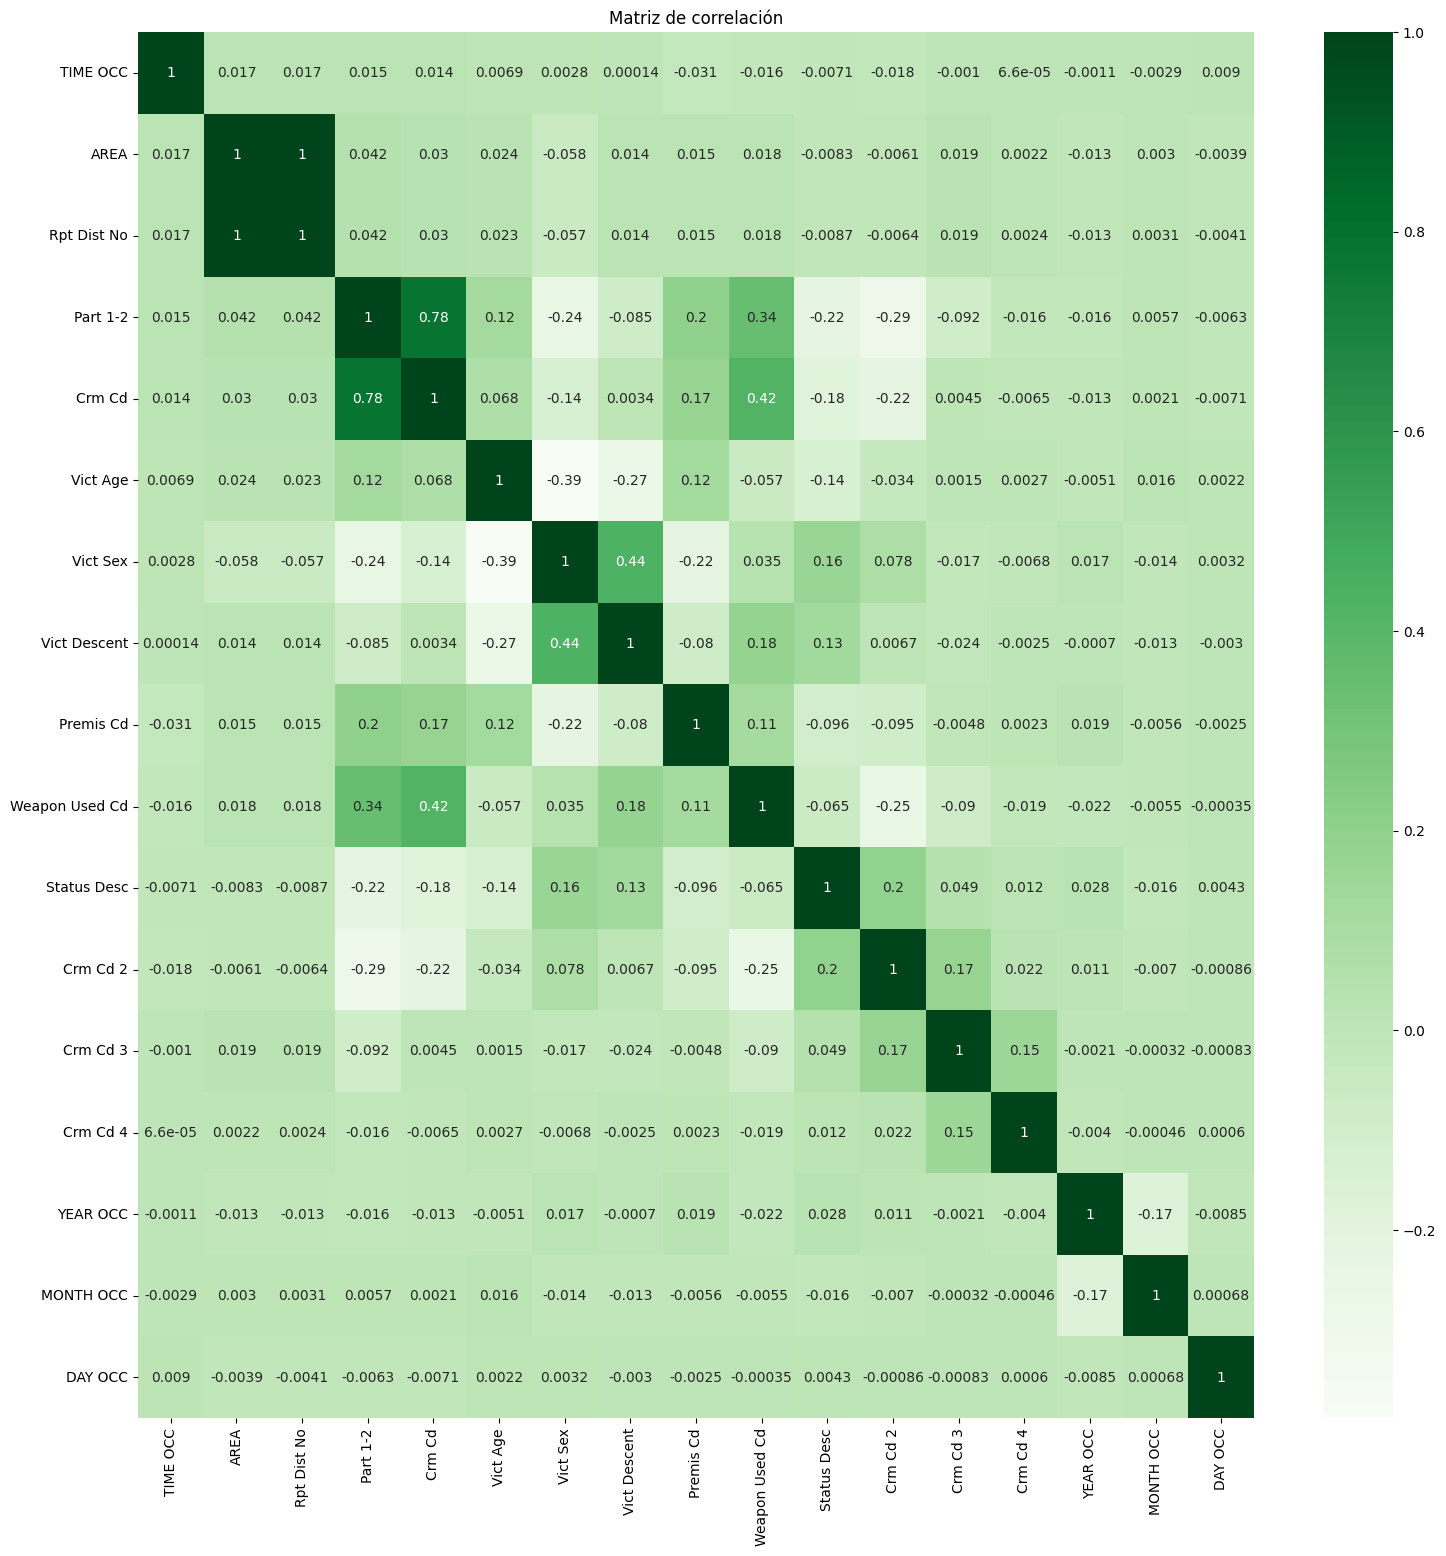

In [15]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(18,18))
sns.heatmap(corr, annot=True, cmap="Greens")

plt.title("Matriz de correlación")

plt.show()

In [16]:
df.head()

,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Vict Sex,Vict Descent,Premis Cd,Weapon Used Cd,Status Desc,Crm Cd 2,Crm Cd 3,Crm Cd 4,YEAR OCC,MONTH OCC,DAY OCC
0,2230,3,377,2,624,36,0,1,501,400,0,0,0,0,2020,1,8
1,1200,1,155,2,845,0,2,16,726,500,1,0,0,0,2020,2,13
2,1925,17,1708,1,341,0,2,16,203,500,0,0,0,0,2020,5,26
3,1355,1,162,1,341,41,1,0,503,500,1,0,0,0,2020,1,5
4,2018,11,1124,2,626,34,0,6,501,400,0,0,0,0,2020,11,28


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151333 entries, 0 to 151332
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   TIME OCC        151333 non-null  int64
 1   AREA            151333 non-null  int64
 2   Rpt Dist No     151333 non-null  int64
 3   Part 1-2        151333 non-null  int64
 4   Crm Cd          151333 non-null  int64
 5   Vict Age        151333 non-null  int64
 6   Vict Sex        151333 non-null  int64
 7   Vict Descent    151333 non-null  int64
 8   Premis Cd       151333 non-null  int64
 9   Weapon Used Cd  151333 non-null  int64
 10  Status Desc     151333 non-null  int64
 11  Crm Cd 2        151333 non-null  int64
 12  Crm Cd 3        151333 non-null  int64
 13  Crm Cd 4        151333 non-null  int64
 14  YEAR OCC        151333 non-null  int32
 15  MONTH OCC       151333 non-null  int32
 16  DAY OCC         151333 non-null  int32
dtypes: int32(3), int64(14)
memory usage: 17.9 MB


## 🔀 División train/test

En Machine Learning no evaluamos el modelo con los mismos datos con los que lo entrenamos.

- **Train (entrenamiento):** el modelo aprende patrones
- **Test (evaluación):** comprobamos si generaliza bien a datos nuevos

👉 Si no hacemos esta separación, el modelo puede parecer muy bueno pero fallar en la realidad (overfitting)


In [18]:

 
X = df.drop(columns=['Status Desc'])
# X = df.drop('Status Desc', axis=1)
y = df['Status Desc']

# Dividimos en 80% entrenamiento y 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (121066, 16)
Test size: (30267, 16)


In [19]:
X_train.head()

,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Vict Sex,Vict Descent,Premis Cd,Weapon Used Cd,Crm Cd 2,Crm Cd 3,Crm Cd 4,YEAR OCC,MONTH OCC,DAY OCC
114266,1955,16,1612,1,230,27,1,10,301,205,998,0,0,2022,1,4
37390,1540,13,1367,2,626,33,1,6,501,400,0,0,0,2020,4,7
45035,1200,17,1797,2,626,44,0,6,501,400,0,0,0,2020,9,25
46765,1640,13,1347,2,623,0,1,6,101,400,0,0,0,2020,3,8
141241,1900,18,1806,1,820,5,0,6,501,400,820,998,0,2023,4,23


## ⚖️ Escalado

In [20]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Entrenamiento de modelos


## 🔵 Regresión Logística

### Explicación del código:
- `LogisticRegression()` crea el modelo
- `.fit(X_train, y_train)` entrena el modelo con los datos
- `.predict(X_test)` hace predicciones
- `accuracy_score` mide el rendimiento


In [21]:

model = LogisticRegression()

# Entrenamos el modelo
model.fit(X_train, y_train)

# Predecimos
preds = model.predict(X_test)
print(X_test.shape)
print(y_test.shape, preds.shape)
# Evaluamos
print("Accuracy:", accuracy_score(y_test, preds))


(30267, 16)
(30267,) (30267,)
Accuracy: 0.6418872038854198



## 🟢 KNN

### Explicación del código:
- `n_neighbors=5` → usa los 5 vecinos más cercanos
- El modelo NO aprende una fórmula → guarda los datos
- Para predecir: busca los puntos más cercanos


In [22]:

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))


Accuracy: 0.6159513661743813



## 🌳 Árbol de decisión

### Explicación del código:
- `max_depth=4` limita la profundidad del árbol
- El modelo crea reglas tipo:
  "si edad < 30 → ..."
- Más profundidad = más complejidad (riesgo de overfitting)


In [23]:

model = DecisionTreeClassifier(max_depth=4)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))


Accuracy: 0.6549046816665015



## 🌲 Random Forest

### Explicación del código:
- `n_estimators=100` → número de árboles
- Cada árbol aprende algo distinto
- El resultado final es la media/votación de todos


In [24]:

model = RandomForestClassifier(n_estimators=50)

model.fit(X_train, y_train)

preds = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, preds))


Accuracy: 0.6861928833382892



## ⚫ SVM

### Explicación del código:
- Busca la mejor frontera de separación entre clases
- Usa hiperplanos (líneas en 2D)
- Muy potente en datasets complejos


In [25]:

# model = SVC()

# model.fit(X_train, y_train)

# preds = model.predict(X_test)

# print("Accuracy:", accuracy_score(y_test, preds))


# CONCLUSION FINAL
Debido a que se ha creado el dataset codificado haciendo label encoding a variables con mucha cardinalidad la mejor opcion es el algoritmo de entrenamiento Random Forest y aparte que es la mejor puntuacion acuraccy.

## Pipeline

In [26]:
pipelineRandomForest = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=50))
])

pipelineRandomForest.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [27]:
joblib.dump(pipelineRandomForest, "..\\models\\crime_data_model.pkl")

['..\\models\\crime_data_model.pkl']

In [28]:
features = pd.DataFrame([{
        "TIME OCC": 1845,
        "AREA": 17,
        "Rpt Dist No": 1738,
        "Part 1-2": 1,
        "Crm Cd": 210,
        "Vict Age": 2,
        "Vict Sex": 1,
        "Vict Descent": 6,
        "Premis Cd": 101,
        "Weapon Used Cd": 311,
        "Crm Cd 2": 10,
		"Crm Cd 3": 10,
		"Crm Cd 4": 10,
		"YEAR OCC": 2021,
		"MONTH OCC": 6,
		"DAY OCC": 2,
    }])
print(pipelineRandomForest.predict(features))
								
# 1845	17	1738	1	210	63	1	6	101	311	0	0	0	32477	2021	6	2

[1]


c:\Users\errec\Documents\Python B1\Runojanh-NadieEscapa\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
